# Notebook 10: Event Frequency and Schedule Robustness

**Research aim.** This notebook examines how event frequency and schedule regularity affect event detection, lag interpretation, event-profile recovery and event-aware volatility forecasting. The experiment keeps the scalar calibration and Known-DGP response shape fixed while comparing dense periodic, sparse periodic and sparse irregular calendars. Within each of 50 repetitions, identical epsilon and eta shocks are used for all schedules, so comparisons are paired. Step 2 is omitted: observable conditional structure is already examined in Notebook 02.

## 1. Common setup and schedule definitions

Event age 0-12 maps to direct response lags +1 to +13 under the frozen timing convention. Each pipeline uses a chronological train/test split, non-overlapping response windows and deployable forecasting inputs. The compact calculations below reuse the Notebook 06 workflow and the completed repeated-seed outputs.

In [1]:
%%capture _helpers_loaded
%run "./06_experiment_workflow_helpers.ipynb"
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display
BENCHMARK_SEED=20260721
REPRESENTATIVE_ROBUSTNESS_SEED=20260722
N_PAIRED_SEEDS=50
STEPS=252; H=13; P_INDIVIDUAL_ROBUSTNESS=13; F_TOL=1e-10; COND_MAX=1e10
GC_PMAX_ROBUSTNESS={'dense_periodic':20,'sparse_periodic':41,'sparse_irregular':42}
RESULTS=Path('notebook10_results')
LABEL={'dense_periodic':'Dense periodic','sparse_periodic':'Sparse periodic','sparse_irregular':'Sparse irregular'}; COLOR={'dense_periodic':'tab:blue','sparse_periodic':'tab:orange','sparse_irregular':'tab:green'}
dense=make_case_config(reference_config,label='dense_periodic'); sparse=make_case_config(dense,{'events.period':42/252},label='sparse_periodic'); irregular=make_case_config(sparse,label='sparse_irregular')
CONFIG={'dense_periodic':dense,'sparse_periodic':sparse,'sparse_irregular':irregular}
STEPS_BY_CASE={'dense_periodic':np.arange(21,484,21),'sparse_periodic':np.arange(21,484,42),'sparse_irregular':np.array([21,52,113,134,203,249,276,302,364,396,449,483])}
case_results=pd.read_csv(RESULTS/'stage4_seed_case_analysis.csv'); tdmi_raw=pd.read_csv(RESULTS/'stage3_tdmi_curve.csv'); profiles=pd.read_csv(RESULTS/'stage4_profile_age_summary.csv')
profile_repeated=case_results[['market_seed','case_name','A_hat','lambda_hat','event_amplitude','event_decay_rate','A_error','lambda_error','parametric_profile_RMSE','nonparametric_profile_RMSE']].copy()
forecast_repeated=case_results[['market_seed','case_name','active_sigma_unaware_MAE','active_sigma_parametric_MAE','active_sigma_nonparametric_MAE','active_sigma_unaware_RMSE','active_sigma_parametric_RMSE','active_sigma_nonparametric_RMSE','active_sigma_parametric_MAE_gain_pct','active_sigma_nonparametric_MAE_gain_pct']].copy()
calibration_repeated=case_results[['market_seed','case_name','active_95_state_parametric_coverage','parametric_absolute_coverage_error','active_95_state_parametric_interval_score']].copy()
assert reference_config['simulation']['seed']==BENCHMARK_SEED and len(case_results)==150 and case_results.market_seed.nunique()==N_PAIRED_SEEDS
assert P_INDIVIDUAL_ROBUSTNESS==13 and derive_timing(dense)['response_horizon_steps']==12
print('Notebook 06 helpers loaded; benchmark and paired-robustness configurations are separate.')

,schedule,events,mean spacing,minimum spacing,maximum spacing,periodic status,windows overlap
0,Dense periodic,23,21.0,21,21,True,False
1,Sparse periodic,12,42.0,42,42,True,False
2,Sparse irregular,12,42.0,21,69,False,False


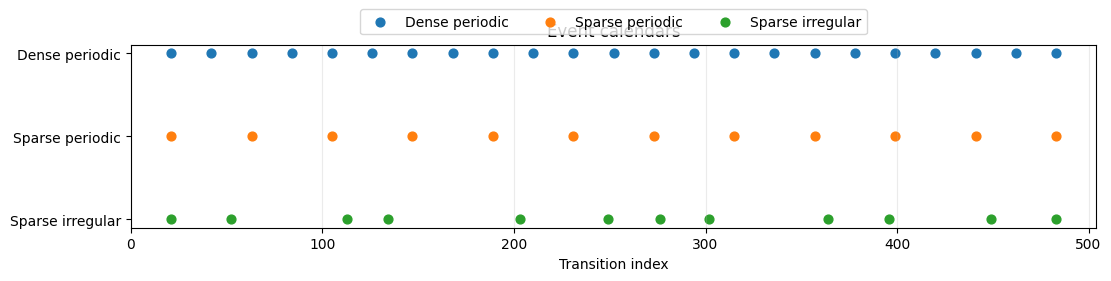

In [2]:
def no_overlap(x): return bool(np.all(np.diff(x)>=H))
schedule=pd.DataFrame([{'schedule':LABEL[k],'events':len(v),'mean spacing':np.diff(v).mean(),'minimum spacing':np.diff(v).min(),'maximum spacing':np.diff(v).max(),'periodic status':k!='sparse_irregular','windows overlap':not no_overlap(v)} for k,v in STEPS_BY_CASE.items()])
display(schedule.style.format({'mean spacing':'{:.1f}'}))
assert all(no_overlap(x) for x in STEPS_BY_CASE.values()) and len(STEPS_BY_CASE['sparse_periodic'])==len(STEPS_BY_CASE['sparse_irregular'])==12
fig,ax=plt.subplots(figsize=(11,2.7),constrained_layout=True)
for y,k in zip([2,1,0],LABEL): ax.scatter(STEPS_BY_CASE[k],np.full(len(STEPS_BY_CASE[k]),y),color=COLOR[k],s=40,label=LABEL[k])
ax.set(yticks=[0,1,2],yticklabels=[LABEL[k] for k in list(LABEL)[::-1]],xlabel='Transition index',xlim=(0,504),title='Event calendars')
ax.grid(axis='x',alpha=.25); ax.legend(ncol=3,loc='lower center',bbox_to_anchor=(.5,1.02)); plt.show()

## Dense periodic benchmark reproduction

Before changing the event schedule, this section verifies that the dense-periodic implementation reproduces the established benchmark results from Notebooks 01, 03, 04 and 05 when the same synthetic path and methodology are used. The later 50-seed analysis answers a different robustness question and is not expected to equal a single canonical-path result.

In [3]:
from IPython.utils.capture import capture_output
# Load established executed methodologies silently, then reproduce each calculation on the frozen canonical path.
with capture_output(): get_ipython().run_line_magic('run','"./00_model_specification_and_core_simulator.ipynb"')
source00=reference_result
with capture_output(): get_ipython().run_line_magic('run','"./01_dense_periodic_n1_gc_tdmi.ipynb"')
source_gc=gc_scan.copy(); source_ind=individual_lag_table.copy(); source_select=gc_order_selection_table.copy(); source_strongest=strongest_individual_lag_table.copy(); source_level_tdmi=level_tdmi.copy(); source_change_tdmi=change_tdmi.copy(); source_tdmi_best=tdmi_best_lag_table.copy(); source_specs=list(gc_specs); source_map={k:(np.asarray(v[0]).copy(),np.asarray(v[1]).copy()) for k,v in series_map.items()}; source_constants=(DIRECT_END,INTER_EVENT_END,NEXT_EVENT_BOUNDARY,TDMI_MAX_LAG,GC_MAX_ORDER)
with capture_output(): get_ipython().run_line_magic('run','"./03_dense_periodic_n1_event_weight_estimation.ipynb"')
source03=(float(A_hat),float(lambda_hat),age_profile.copy(),active_train_proxy.copy(),profile_error_table.copy(),parameter_comparison.copy())
with capture_output(): get_ipython().run_line_magic('run','"./04_dense_periodic_n1_volatility_forecasting.ipynb"')
source04=(test_forecast_table.copy(),test_data.copy(),frozen_ols_coefficients.copy(),float(frozen_A_hat),float(frozen_lambda_hat),frozen_nonparametric_profile.copy())
with capture_output(): get_ipython().run_line_magic('run','"./05_dense_periodic_n1_forecast_evaluation.ipynb"')
source05=(accuracy_table.copy(),relative_gain_table.copy(),interval_table.copy(),calibration_table.copy(),int(hac_lag))
# Notebook 00 path: regenerate the canonical simulator arrays from frozen inputs.
canonical_events=periodic_event_times(time_grid[0],time_grid[-2],reference_config['events'])
reproduced00=simulate_event_volatility(time_grid=time_grid,S0=reference_config['simulation']['S0'],sigma0=reference_config['simulation']['sigma0'],n=reference_config['model']['n'],alpha_fn=alpha_fn,nu_fn=nu_fn,rho_fn=rho_fn,event_weight_fn=event_weight_fn,model_params=reference_config['model'],event_times=canonical_events,event_params=reference_config['events'],seed=BENCHMARK_SEED)
def mdiff(a,b):
 a,b=np.asarray(a,float),np.asarray(b,float); assert a.shape==b.shape and np.array_equal(np.isnan(a),np.isnan(b)); return float(np.nanmax(np.abs(a-b))) if np.isfinite(a).any() else 0.0
def fcols(a,b,cols): return max(mdiff(a[c],b[c]) for c in cols)
array_diff=max(mdiff(reproduced00['states'][c],source00['states'][c]) for c in ['S','sigma','x'])
array_diff=max(array_diff,mdiff(reproduced00['transitions']['omega_next'],source00['transitions']['omega_next']))
assert np.array_equal(reproduced00['transitions']['event'],source00['transitions']['event']) and array_diff<=1e-12
# Notebook 01 exact settings: source functions retain p=20 conditioning and reverse-boundary rules.
DIRECT_END,INTER_EVENT_END,NEXT_EVENT_BOUNDARY,TDMI_MAX_LAG,GC_MAX_ORDER=source_constants
re_gc=pd.concat([run_gc_order_scan(y,z,n,d) for n,d,y,z in source_specs],ignore_index=True)
re_ind=pd.concat([run_individual_lag_tests(y,z,n,d) for n,d,y,z in source_specs],ignore_index=True)
re_level=compute_tdmi_curve(source_map['Powered-state level'][1],source_map['Powered-state level'][0]); re_change=compute_tdmi_curve(source_map['Powered-state change'][1],source_map['Powered-state change'][0])
re_best=pd.concat([summarise_tdmi_windows(re_level,'Powered-state level'),summarise_tdmi_windows(re_change,'Powered-state change')],ignore_index=True)
gc_diff=fcols(source_gc,re_gc,['F_statistic','p_value','partial_R_squared','unrestricted_AIC','unrestricted_BIC']); ind_diff=fcols(source_ind,re_ind,['coefficient','partial_F_statistic','raw_p_value','Holm_adjusted_p_value']); tdmi_level_diff=mdiff(source_level_tdmi.mutual_information,re_level.mutual_information); tdmi_change_diff=mdiff(source_change_tdmi.mutual_information,re_change.mutual_information)
assert max(gc_diff,ind_diff,tdmi_level_diff,tdmi_change_diff)<=1e-12
assert source_tdmi_best[['target','window','best lag']].equals(re_best[['target','window','best lag']])

# Exact Notebook 01 order-selection and strongest-lag parity (not the later p=13 robustness specification).
re_select_rows=[]; re_strong_rows=[]
for target_name,direction,_,_ in source_specs:
    scan=re_gc.loc[re_gc.direction.eq(direction)]
    re_select_rows += [select_gc_orders(scan,DIRECT_END,'direct response p=1..13'),select_gc_orders(scan,INTER_EVENT_END,'strict inter-event p=1..20')]
    lags=re_ind.loc[re_ind.direction.eq(direction)]
    direct=lags.loc[lags.lag.between(1,DIRECT_END)].nlargest(1,'partial_F_statistic').iloc[0]
    inter_end=GC_MAX_ORDER-1 if direction in REVERSE_GC_DIRECTIONS else GC_MAX_ORDER
    inter=lags.loc[lags.lag.between(1,inter_end)].nlargest(1,'partial_F_statistic').iloc[0]
    for label,row in [('direct response lag=1..13',direct),(f'valid inter-event lag=1..{inter_end}',inter)]:
        re_strong_rows.append({'target':target_name,'direction':direction,'lag window':label,'strongest lag':int(row.lag),'coefficient':float(row.coefficient),'partial F-statistic':float(row.partial_F_statistic),'raw p-value':float(row.raw_p_value),'Holm-adjusted p-value':float(row.Holm_adjusted_p_value)})
re_select=pd.DataFrame(re_select_rows); re_strong=pd.DataFrame(re_strong_rows)
assert source_select[['AIC-selected order','BIC-selected order','max-partial-R2 order']].equals(re_select[['AIC-selected order','BIC-selected order','max-partial-R2 order']])
assert source_strongest[['target','direction','lag window','strongest lag']].equals(re_strong[['target','direction','lag window','strongest lag']])
assert fcols(source_strongest,re_strong,['coefficient','partial F-statistic','raw p-value','Holm-adjusted p-value'])<=1e-12
# Event-age mapping is source-time event age 0..12; the held-out indices and age labels must agree exactly.
re_test_ages=[]
source_event=np.asarray(source00['transitions']['event'],int)
for i in source04[0]['i'].to_numpy(int):
    prior=np.flatnonzero(source_event[:i+1])
    age=i-prior[-1] if prior.size else -1
    re_test_ages.append(age if 0<=age<=12 else -1)
assert np.array_equal(source04[0]['event_age_i'].to_numpy(int),np.asarray(re_test_ages,int))

# Notebook 03 exact observable profile construction.
a03,l03,age03,train03,error03,param03=source03
re_param=1+a03*np.exp(-l03*np.arange(13)/252); re_non=train03.groupby('event_age_i')['m_raw_nonparametric'].mean().reindex(range(13)).to_numpy()**2
profile_diff=max(mdiff(1+a03*np.exp(-l03*np.arange(13)/252),re_param),mdiff(age03.omega_hat_nonparametric,re_non)); assert profile_diff<=1e-12
# Notebook 04 exact frozen forecast arrays, reconstructed using only fitted training quantities and test-time inputs.
f04,t04,params04,a04,l04,np04=source04
re_forecast=f04[['i','target_i','sigma_i','epsilon_proxy_i','event_active_i','event_age_i','event_age_years_i']].copy(); X=sm.add_constant(re_forecast[['sigma_i','epsilon_proxy_i']],has_constant='add'); re_forecast['sigma_forecast_unaware']=np.asarray(X@params04,float); active=re_forecast.event_active_i.eq(1); re_forecast['sigma_forecast_parametric']=re_forecast.sigma_forecast_unaware; re_forecast.loc[active,'sigma_forecast_parametric']*=np.sqrt(1+a04*np.exp(-l04*re_forecast.loc[active,'event_age_years_i'])); re_forecast['sigma_forecast_nonparametric']=re_forecast.sigma_forecast_unaware; re_forecast.loc[active,'sigma_forecast_nonparametric']*=re_forecast.loc[active,'event_age_i'].map(np04)
fcols04=['sigma_forecast_unaware','sigma_forecast_parametric','sigma_forecast_nonparametric']; forecast_diff=fcols(f04,re_forecast,fcols04); assert forecast_diff<=1e-12 and 'sigma_next' not in re_forecast
# Notebook 05 exact performance and HAC calibration from reproduced forecasts.
a05,g05,i05,c05,h05=source05; ev=re_forecast.merge(t04[['i','target_i','sigma_next']],on=['i','target_i'],validate='one_to_one'); labels={'sigma_forecast_unaware':'Event-unaware','sigma_forecast_parametric':'Parametric event-aware','sigma_forecast_nonparametric':'Non-parametric event-aware'}; rows=[]
for subset,mask in [('All test',pd.Series(True,index=ev.index)),('Active',ev.event_active_i.eq(1)),('Event-free',ev.event_active_i.eq(0))]:
 for col,label in labels.items():
  err=ev.loc[mask,'sigma_next']-ev.loc[mask,col]; rows.append({'subset':subset,'model':label,'MAE':err.abs().mean(),'RMSE':np.sqrt(np.mean(err**2)),'bias':err.mean()})
re_accuracy=pd.DataFrame(rows); gain=[]
for subset in ['All test','Active']:
 base=re_accuracy.query("subset==@subset and model=='Event-unaware'").iloc[0]
 for label in ['Parametric event-aware','Non-parametric event-aware']:
  q=re_accuracy.query('subset==@subset and model==@label').iloc[0]; gain.append({'subset':subset,'model':label,'MAE_gain_percent':100*(1-q.MAE/base.MAE),'RMSE_gain_percent':100*(1-q.RMSE/base.RMSE)})
re_gain=pd.DataFrame(gain); perf_diff=max(fcols(a05,re_accuracy,['MAE','RMSE','bias']),fcols(g05,re_gain,['MAE_gain_percent','RMSE_gain_percent']))
cal=[]
for subset,mask in [('All test',pd.Series(True,index=ev.index)),('Active',ev.event_active_i.eq(1))]:
 for col,label in labels.items():
  fit=sm.OLS(ev.loc[mask,'sigma_next'],sm.add_constant(ev.loc[mask,col],has_constant='add')).fit(cov_type='HAC',cov_kwds={'maxlags':h05}); w=fit.wald_test((np.eye(2),np.array([0.,1.])),scalar=True); cal.append({'subset':subset,'model':label,'intercept':fit.params['const'],'intercept_se':fit.bse['const'],'slope':fit.params[col],'slope_se':fit.bse[col],'joint_wald_statistic':float(w.statistic),'joint_p_value':float(w.pvalue)})
re_cal=pd.DataFrame(cal); cal_diff=fcols(c05,re_cal,['intercept','intercept_se','slope','slope_se','joint_wald_statistic','joint_p_value']); assert perf_diff<=1e-12 and cal_diff<=1e-12
parity=[('Notebook 00','synthetic arrays','max array difference',array_diff),('Notebook 01','GC curves','max curve difference',gc_diff),('Notebook 01','individual lags','max lag-statistic difference',ind_diff),('Notebook 01','TDMI level','max signed-lag difference',tdmi_level_diff),('Notebook 01','TDMI change','max signed-lag difference',tdmi_change_diff),('Notebook 03','event profiles','max profile difference',profile_diff),('Notebook 04','forecast arrays','max forecast difference',forecast_diff),('Notebook 05','accuracy metrics','max metric difference',perf_diff),('Notebook 05','calibration metrics','max metric difference',cal_diff)]
benchmark_parity_table=pd.DataFrame(parity,columns=['source notebook','component','metric','absolute difference']); benchmark_parity_table['tolerance']=1e-12; benchmark_parity_table['pass']=benchmark_parity_table['absolute difference'].le(benchmark_parity_table.tolerance); assert benchmark_parity_table['pass'].all(); MAX_BENCHMARK_PARITY_DIFFERENCE=float(benchmark_parity_table['absolute difference'].max()); display(benchmark_parity_table); print('Dense benchmark reproduction passed.')

,source notebook,component,metric,absolute difference,tolerance,pass
0,Notebook 00,synthetic arrays,max array difference,0.0,1.000000e-12,True
1,Notebook 01,GC curves,max curve difference,0.0,1.000000e-12,True
2,Notebook 01,individual lags,max lag-statistic difference,0.0,1.000000e-12,True
3,Notebook 01,TDMI level,max signed-lag difference,0.0,1.000000e-12,True
4,Notebook 01,TDMI change,max signed-lag difference,0.0,1.000000e-12,True
5,Notebook 03,event profiles,max profile difference,0.0,1.000000e-12,True
6,Notebook 04,forecast arrays,max forecast difference,0.0,1.000000e-12,True
7,Notebook 05,accuracy metrics,max metric difference,0.0,1.000000e-12,True
8,Notebook 05,calibration metrics,max metric difference,0.0,1.000000e-12,True


Dense benchmark reproduction passed.


The benchmark reproduction above uses the exact canonical path and methodology of the earlier notebooks. The following schedule-robustness analysis uses 50 paired shock realisations and a common comparison specification. Its medians, rejection rates, selected orders and lag frequencies are therefore not expected to equal the single-path benchmark.

Notebook 01's exact conditioning specification is reproduced above. The robustness comparison below uses a common direct-window individual-lag specification to make dense, sparse-periodic and sparse-irregular schedules comparable.

## 2. Dense periodic analysis

Dense periodic has 23 events and a next-event boundary at 21 transitions. GC is **linear directional predictive evidence**: cumulative order p contains driver lags 1, ..., p. Individual lag j is tested conditionally on target history and all other event-history lags; it is not the same object as selected cumulative order p.

In [4]:
# Explicit historical GC directions. Forward: event history predicts powered-state target.
# Reverse: powered-state history predicts the binary predetermined event indicator (linear-probability-style diagnostic).
def lag_design(target_series,driver_series,p,common_max):
    target=np.asarray(target_series,float); driver=np.asarray(driver_series,float)
    if len(target)!=len(driver) or not (1<=p<=common_max<len(target)): raise ValueError('invalid GC lag specification')
    t=np.arange(common_max,len(target)); own=np.column_stack([target[t-j] for j in range(1,p+1)]); drv=np.column_stack([driver[t-j] for j in range(1,p+1)])
    columns=['const']+[f'target_lag_{j}' for j in range(1,p+1)]+[f'event_lag_{j}' for j in range(1,p+1)]
    X=np.column_stack([np.ones(len(t)),own,drv]); return target[t],X,columns

def run_gc_direction(target_series,driver_series,p,direction_label,common_max):
    y,Xu,columns=lag_design(target_series,driver_series,p,common_max); Xr=Xu[:,:p+1]
    rank_u,rank_r=np.linalg.matrix_rank(Xu),np.linalg.matrix_rank(Xr); cond=float(np.linalg.cond(Xu)); valid=(rank_u==Xu.shape[1] and rank_r==Xr.shape[1] and np.isfinite(cond) and cond<=COND_MAX)
    row={'direction':direction_label,'order':p,'n_observations':len(y),'n_columns':Xu.shape[1],'rank':rank_u,'condition_number':cond,'valid_rank':valid,'conditioning_ok':bool(np.isfinite(cond) and cond<=COND_MAX)}
    if not valid: return row
    unrestricted=sm.OLS(y,Xu).fit(method='qr'); q=p; R=np.zeros((q,Xu.shape[1])); R[:,p+1:]=np.eye(q); test=unrestricted.f_test(R); F=float(np.asarray(test.fvalue).squeeze()); p_value=float(np.asarray(test.pvalue).squeeze())
    if -F_TOL<=F<0: F,p_value=0.0,1.0
    if F<-F_TOL: raise RuntimeError(f'negative joint F beyond tolerance: {direction_label}, p={p}')
    assert np.isfinite(F) and F>=0 and 0<=p_value<=1
    row.update({'F':F,'p_value':p_value,'partial_r2':float((F*q)/(F*q+unrestricted.df_resid)),'aic':float(unrestricted.aic),'bic':float(unrestricted.bic)})
    return row

def series_pair(table,target_name,direction):
    state=table.state_i.to_numpy(float); event=table.event_i.to_numpy(float)
    if target_name=='change': state,event=np.diff(state),event[1:]
    return (state,event) if direction=='forward' else (event,state)

def gc_scan(table,case,target,direction,pmax):
    y,d=series_pair(table,target,direction); rows=[]
    for p in range(1,pmax+1):
        r=run_gc_direction(y,d,p,direction,pmax); r.update({'case':case,'target':target}); rows.append(r)
    return pd.DataFrame(rows)

def individual_lags(table,case,target):
    y,event=series_pair(table,target,'forward'); y,X,columns=lag_design(y,event,P_INDIVIDUAL_ROBUSTNESS,P_INDIVIDUAL_ROBUSTNESS); rank=np.linalg.matrix_rank(X); condition=float(np.linalg.cond(X))
    if rank!=X.shape[1]: raise RuntimeError(f'rank-deficient individual-lag design: {case}, {target}, forward, p={P_INDIVIDUAL_ROBUSTNESS}')
    fit=sm.OLS(y,X).fit(); rows=[]
    for j in range(1,P_INDIVIDUAL_ROBUSTNESS+1):
        index=1+P_INDIVIDUAL_ROBUSTNESS+(j-1); R=np.zeros((1,X.shape[1])); R[0,index]=1.0; test=fit.f_test(R); F=float(np.asarray(test.fvalue).squeeze()); p_value=float(np.asarray(test.pvalue).squeeze())
        if -F_TOL<=F<0: F,p_value=0.0,1.0
        if F<-F_TOL: raise RuntimeError(f'negative individual F beyond tolerance: {case}, {target}, j={j}')
        assert np.isfinite(F) and F>=0 and 0<=p_value<=1
        rows.append({'case':case,'target':target,'direction':'forward','individual_order':P_INDIVIDUAL_ROBUSTNESS,'lag':j,'coefficient':float(fit.params[index]),'partial_F':F,'p_value':p_value,'rank':rank,'n_columns':X.shape[1],'condition_number':condition})
    out=pd.DataFrame(rows); out['holm_p']=multipletests(out.p_value,method='holm')[1]; out['holm_reject']=out.holm_p<.05; return out

def make_table(case,seed):
    shocks=make_shock_bank(dense,seed=int(seed)); timing=derive_timing(CONFIG[case]); simulation=simulate_case(CONFIG[case],shocks,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing)['simulation']; return build_transition_table(simulation,CONFIG[case],timing)[0],simulation['transitions']
# Corrected canonical GC object: repeated direct-window selection plus representative full valid scans.
gc_rows=[]; individual_rows=[]; gc_design_diagnostics=[]; seeds=sorted(case_results.market_seed.unique())
for seed in seeds:
    shared=make_shock_bank(dense,seed=int(seed)); trans={}; tables={}
    for case in LABEL:
        timing=derive_timing(CONFIG[case]); sim=simulate_case(CONFIG[case],shared,None,event_schedule=STEPS_BY_CASE[case]/STEPS,_timing=timing)['simulation']; trans[case]=sim['transitions']; tables[case]=build_transition_table(sim,CONFIG[case],timing)[0]
    ref=trans['dense_periodic']; assert all(np.array_equal(x.epsilon.to_numpy(),ref.epsilon.to_numpy()) and np.array_equal(x.eta.to_numpy(),ref.eta.to_numpy()) for x in trans.values())
    for case,table in tables.items():
        for target in ['level','change']:
            for direction in ['forward','reverse']:
                scan=gc_scan(table,case,target,direction,GC_PMAX_ROBUSTNESS[case]); scan['seed']=seed; gc_rows.extend(scan.to_dict('records')); gc_design_diagnostics.extend(scan[['case','seed','target','direction','order','n_observations','n_columns','rank','condition_number','valid_rank']].to_dict('records'))
            individual_rows.extend(individual_lags(table,case,target).assign(seed=seed).to_dict('records'))
gc_repeated=pd.DataFrame(gc_rows); individual_repeated=pd.DataFrame(individual_rows); gc_design_diagnostics=pd.DataFrame(gc_design_diagnostics)
assert len(gc_repeated)==N_PAIRED_SEEDS*2*2*sum(GC_PMAX_ROBUSTNESS.values())
assert gc_design_diagnostics.loc[gc_design_diagnostics.valid_rank,'rank'].eq(gc_design_diagnostics.loc[gc_design_diagnostics.valid_rank,'n_columns']).all()
assert individual_repeated.individual_order.eq(P_INDIVIDUAL_ROBUSTNESS).all() and individual_repeated['rank'].eq(individual_repeated.n_columns).all() and individual_repeated.partial_F.ge(0).all()

In [5]:
def representative_gc(case):
    table,_=make_table(case,REPRESENTATIVE_ROBUSTNESS_SEED); scans=[]
    for target in ['level','change']:
        for direction in ['forward','reverse']:
            scans.append(gc_scan(table,case,target,direction,GC_PMAX_ROBUSTNESS[case]))
    return table,pd.concat(scans,ignore_index=True),pd.concat([individual_lags(table,case,t) for t in ['level','change']],ignore_index=True)
def first_mode(series):
    # Smallest lag breaks a modal-frequency tie deterministically.
    return int(pd.Series(series).dropna().astype(int).mode().min())

def selection_summary(scan):
    valid=scan.loc[scan.valid_rank].dropna(subset=['aic','bic','partial_r2']); a=valid.loc[valid.aic.idxmin()]; b=valid.loc[valid.bic.idxmin()]; m=valid.loc[valid.partial_r2.idxmax()]
    return {'AIC order':int(a.order),'BIC order':int(b.order),'max partial R2 order':int(m.order),'joint F':float(b.F),'joint p':float(b.p_value),'partial R2':float(b.partial_r2)}
def show_gc(case):
    _,scans,individual=representative_gc(case); boundary={'dense_periodic':21,'sparse_periodic':42}.get(case); fig,axes=plt.subplots(2,2,figsize=(13,7),constrained_layout=True); order_rows=[]; strongest=[]
    for r,target in enumerate(['level','change']):
        for direction,style,col in [('forward','-','tab:blue'),('reverse','--','tab:red')]:
            d=scans.query('target==@target and direction==@direction and valid_rank'); axes[r,0].plot(d.order,d.partial_r2,style,color=col,label=direction); order_rows.append({'target':target,'direction':direction,**selection_summary(d)})
        axes[r,0].axvline(13,color='black',ls='--',lw=1,label='direct boundary p=13')
        if boundary: axes[r,0].axvline(boundary,color='grey',ls=':',lw=1,label=f'calendar boundary p={boundary}')
        axes[r,0].set(xlabel='Cumulative GC history order p',ylabel='Joint partial $R^2$',title=f'Powered-state {target}: cumulative sensitivity'); axes[r,0].legend(fontsize=7)
        d=individual.query('target==@target'); top=d.loc[d.partial_F.idxmax()]; strongest.append({'target':target,'lag j':int(top.lag),'coefficient':top.coefficient,'partial F':top.partial_F,'raw p':top.p_value,'Holm p':top.holm_p,'survives Holm':top.holm_reject})
        axes[r,1].stem(d.lag,d.partial_F,basefmt=' ',linefmt='tab:blue',markerfmt='o'); axes[r,1].scatter(top.lag,top.partial_F,color='green',label='strongest valid lag'); axes[r,1].axhline(0,color='black',lw=.8); axes[r,1].axvline(13,color='tab:orange',ls='--',label='direct boundary')
        axes[r,1].set(xlim=(.5,13.5),xticks=np.arange(1,14),xlabel='Individual event lag j',ylabel='Partial $F$-statistic',title=f'Powered-state {target}: direct-window conditional event lags'); axes[r,1].legend(fontsize=7)
    fig.suptitle(f'{LABEL[case]}: GC diagnostics (illustrative robustness seed {REPRESENTATIVE_ROBUSTNESS_SEED})'); plt.show(); display(pd.DataFrame(order_rows).style.format(precision=4)); display(pd.DataFrame(strongest).style.format(precision=4))
    d=gc_repeated.query('case==@case and direction=="forward" and valid_rank'); group=d.groupby(['seed','target']); selected=group.apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series).reset_index(); ind=individual_repeated.query('case==@case').sort_values('partial_F').groupby(['seed','target'],group_keys=False).tail(1)
    across=selected.groupby('target').agg(median_AIC_order=('AIC order','median'),median_BIC_order=('BIC order','median'),rejection_rate=('joint p',lambda x:(x<.05).mean()),median_partial_R2=('partial R2','median')).reset_index().merge(ind.groupby('target').agg(modal_strongest_j=('lag',first_mode),median_strongest_F=('partial_F','median'),Holm_survival_rate=('holm_reject','mean')).reset_index(),on='target'); display(across.style.format(precision=4)); display(ind.groupby(['target','lag']).size().unstack(fill_value=0))


### Step 1 - GC and TDMI analysis

Reverse GC is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

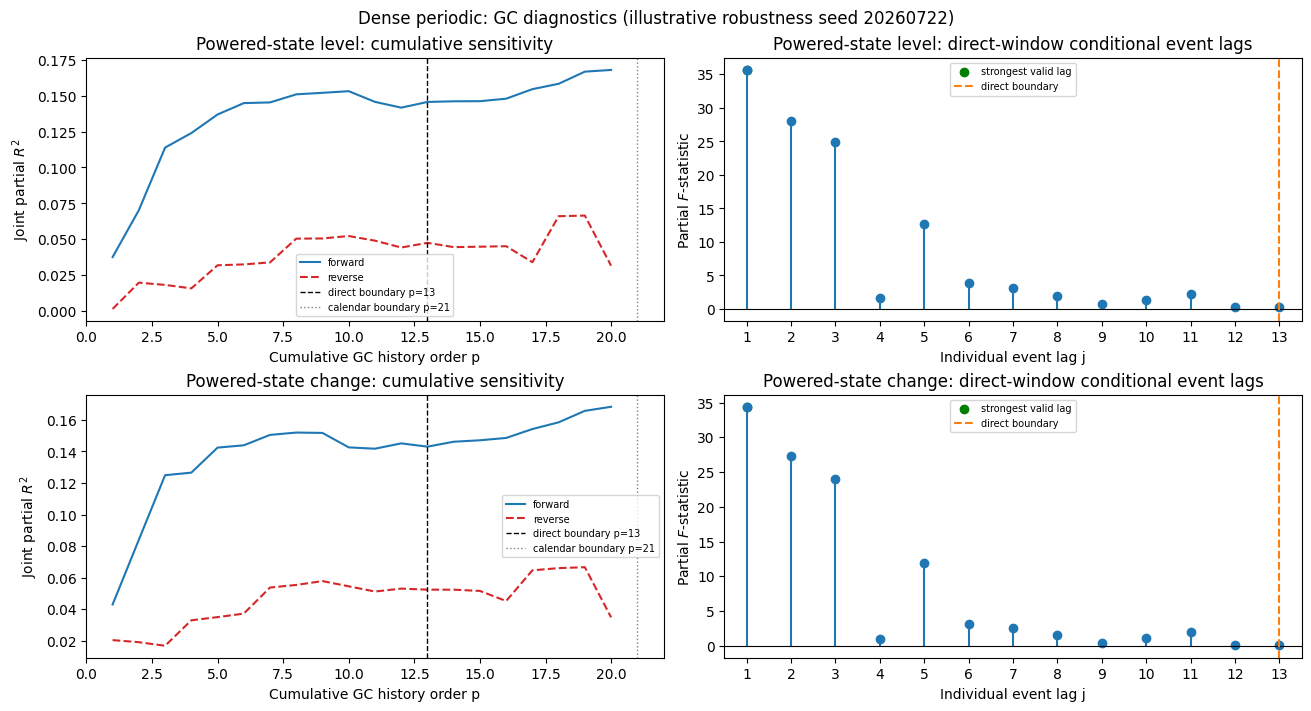

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,6,3,20,19.9091,0.0000,0.1138
1,level,reverse,20,20,19,0.7025,0.8247,0.0316
2,change,forward,5,3,20,22.0725,0.0000,0.1249
3,change,reverse,20,20,19,0.7782,0.7407,0.0349


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0013,35.6528,0.0000,0.0000,True
1,change,1,0.0013,34.3912,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,7.0000,2.0000,0.9800,0.0781,1,32.4762,1.0000
1,level,7.0000,2.0000,1.0000,0.0734,1,31.9281,1.0000


lag,1,2,3,4,5
target,,,,,
change,32,13,3,1,1
level,28,15,5,1,1


In [6]:
show_gc('dense_periodic')

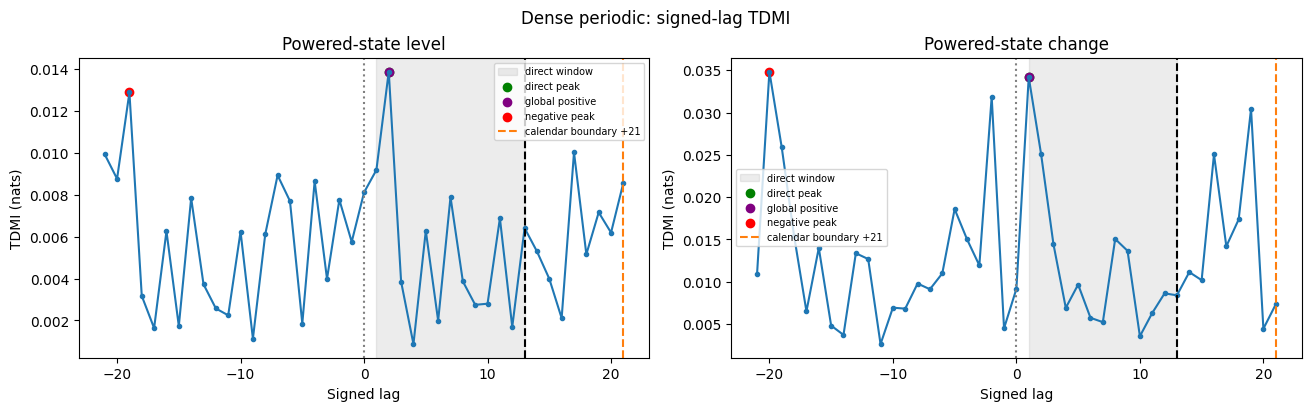

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,2,0.0139,2,0.0139,-19,True,False
1,change,1,0.0342,1,0.0342,-20,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.2800,0.7200,1.0758
1,level,0.0200,0.9800,1.1636


In [7]:
def tdmi_seed_metrics(group):
    rows=[]
    for target,d in group.groupby('target'):
        pos=d.query('lag>0'); direct=pos.query('lag<=13'); outside=pos.query('lag>13'); best=pos.loc[pos.mutual_information.idxmax()]; dmax=direct.mutual_information.max(); omax=outside.mutual_information.max(); neg=d.query('lag<0').loc[d.query('lag<0').mutual_information.idxmax()]
        rows.append({'target':target,'direct_lag':int(direct.loc[direct.mutual_information.idxmax(),'lag']),'direct_max':dmax,'global_positive_lag':int(best.lag),'global_positive_max':best.mutual_information,'negative_lag':int(neg.lag),'negative_max':neg.mutual_information,'global_positive_inside_direct':bool(best.lag<=13),'alias_dominates':bool(omax>dmax),'alias_strength_ratio':np.nan if dmax<=0 else omax/dmax,'scan_boundary':bool(abs(best.lag)==d.lag.abs().max())})
    return pd.DataFrame(rows)
tdmi_repeated=pd.concat([tdmi_seed_metrics(g).assign(seed=s,case=c) for (s,c),g in tdmi_raw.groupby(['market_seed','case_name'])],ignore_index=True)
assert len(tdmi_repeated)==N_PAIRED_SEEDS*3*2 and tdmi_repeated.alias_dominates.isin([True,False]).all() and tdmi_repeated.global_positive_inside_direct.isin([True,False]).all()
def show_tdmi(case):
    seed=REPRESENTATIVE_ROBUSTNESS_SEED if REPRESENTATIVE_ROBUSTNESS_SEED in set(tdmi_raw.market_seed) else tdmi_raw.market_seed.min(); period=21 if case=='dense_periodic' else 42; fig,axes=plt.subplots(1,2,figsize=(13,4),constrained_layout=True); rows=[]
    for ax,target in zip(axes,['level','change']):
        d=tdmi_raw.query('market_seed==@seed and case_name==@case and target==@target and lag.between(-@period,@period)').sort_values('lag'); metric=tdmi_seed_metrics(d).iloc[0]; direct=d.query('lag==@metric.direct_lag').iloc[0]; pos=d.query('lag==@metric.global_positive_lag').iloc[0]; neg=d.query('lag==@metric.negative_lag').iloc[0]
        ax.plot(d.lag,d.mutual_information,marker='o',ms=3); ax.axvline(0,color='grey',ls=':'); ax.axvspan(1,13,color='grey',alpha=.15,label='direct window'); ax.axvline(13,color='black',ls='--');
        for q,c,l in [(direct,'green','direct peak'),(pos,'purple','global positive'),(neg,'red','negative peak')]: ax.scatter(q.lag,q.mutual_information,color=c,label=l)
        if case!='sparse_irregular': ax.axvline(period,color='tab:orange',ls='--',label=f'calendar boundary +{period}')
        ax.set(title=f'Powered-state {target}',xlabel='Signed lag',ylabel='TDMI (nats)'); ax.legend(fontsize=7); rows.append({'target':target,'direct lag':metric.direct_lag,'direct TDMI':metric.direct_max,'global positive lag':metric.global_positive_lag,'global positive TDMI':metric.global_positive_max,'negative lag':metric.negative_lag,'global inside direct':metric.global_positive_inside_direct,'scan boundary':metric.scan_boundary})
    fig.suptitle(f'{LABEL[case]}: signed-lag TDMI'); plt.show(); display(pd.DataFrame(rows).style.format(precision=4)); d=tdmi_repeated.query('case==@case'); display(d.groupby('target').agg(global_positive_inside_direct_rate=('global_positive_inside_direct','mean'),outside_window_dominance_rate=('alias_dominates','mean'),median_outside_direct_ratio=('alias_strength_ratio','median')).reset_index().style.format(precision=4))
show_tdmi('dense_periodic')

In [8]:
def schedule_finding(case):
    g=gc_repeated.query('case==@case and target=="change" and direction=="forward" and valid_rank')
    selected=g.groupby('seed').apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series)
    ind=individual_repeated.query('case==@case and target=="change"').sort_values('partial_F').groupby('seed',group_keys=False).tail(1)
    td=tdmi_repeated.query('case==@case and target=="change"'); pr=profile_repeated.query('case_name==@case'); fo=forecast_repeated.query('case_name==@case'); ca=calibration_repeated.query('case_name==@case')
    display(Markdown(f"{LABEL[case]} finding: forward linear directional predictive evidence rejects in {(selected['joint p']<.05).mean():.0%} of paired seeds; median AIC order is {selected['AIC order'].median():.0f} and the modal strongest direct individual lag is {first_mode(ind.lag)}. TDMI's global positive peak lies outside the direct window in {td.alias_dominates.mean():.0%} of seeds, so it remains unsigned nonlinear lagged dependence rather than structural timing. Mean parametric profile RMSE is {pr.parametric_profile_RMSE.mean():.5f}; median active-window parametric MAE gain is {fo.active_sigma_parametric_MAE_gain_pct.median():.2f}%, with mean absolute 95% coverage error {ca.parametric_absolute_coverage_error.mean():.3f}."))

### Step 3 - Event-weight recovery

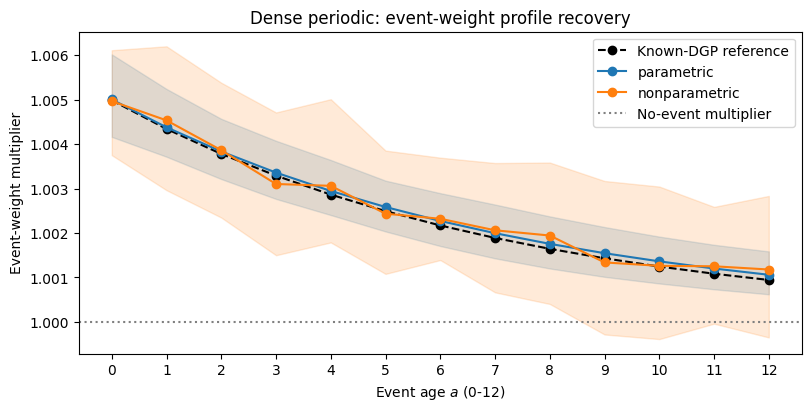

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.01004,0.00004,35.00000,33.48436,-1.51564,0.00034,0.00097


In [9]:
def show_profile(case):
    fig,ax=plt.subplots(figsize=(8,4),constrained_layout=True); d=profiles.query('case_name==@case').sort_values('event_age'); truth=d.groupby('event_age').true_multiplier.first(); ax.plot(truth.index,truth.values,color='black',ls='--',marker='o',label='Known-DGP reference')
    for e,c in [('parametric','tab:blue'),('nonparametric','tab:orange')]: x=d.query('estimator==@e'); ax.plot(x.event_age,x.estimated_multiplier_mean,color=c,marker='o',label=e); ax.fill_between(x.event_age,x.estimated_multiplier_q05,x.estimated_multiplier_q95,color=c,alpha=.16)
    ax.axhline(1,color='grey',ls=':',label='No-event multiplier'); ax.set(xticks=np.arange(13),xlabel='Event age $a$ (0-12)',ylabel='Event-weight multiplier',title=f'{LABEL[case]}: event-weight profile recovery'); ax.legend(); plt.show(); display(Markdown('Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.'))
    z=profile_repeated.query('case_name==@case'); row=z.iloc[0]; display(pd.DataFrame([{'true amplitude':row.event_amplitude,'estimated amplitude':z.A_hat.mean(),'amplitude error':z.A_error.mean(),'true decay':row.event_decay_rate,'estimated decay':z.lambda_hat.mean(),'decay error':z.lambda_error.mean(),'parametric profile RMSE':z.parametric_profile_RMSE.mean(),'non-parametric profile RMSE':z.nonparametric_profile_RMSE.mean()}]).style.format(precision=5))
show_profile('dense_periodic')

In [10]:
def representative_forecast(case):
    table,_=make_table(case,REPRESENTATIVE_ROBUSTNESS_SEED); timing=derive_timing(CONFIG[case]); split=create_chronological_split(table,timing); baseline=fit_event_free_baseline(split['train'],CONFIG[case],build_baseline_features); profile=estimate_event_profiles(split['train'],baseline,CONFIG[case],timing,build_baseline_features); forecasts=construct_forecasts(split['test'],baseline,profile,CONFIG[case],timing,build_baseline_features); assert {'state_next','sigma_next','omega','eta'}.isdisjoint(forecasts.columns); return evaluate_forecasts(forecasts,split['test'],CONFIG[case])['evaluation']
def show_forecast(case, show_metrics=True):
    d=representative_forecast(case); fig,ax=plt.subplots(figsize=(12,4),constrained_layout=True); ax.plot(d.target_i,d.sigma_next,color='black',lw=1.5,label='Realised volatility')
    for c,l,col in [('sigma_forecast_unaware','Event-unaware','grey'),('sigma_forecast_parametric','Parametric event-aware','tab:blue'),('sigma_forecast_nonparametric','Non-parametric event-aware','tab:orange')]: ax.plot(d.target_i,d[c],color=col,lw=1.1,label=l)
    active=d.event_active_i.eq(1).to_numpy(); starts=d.loc[active&~np.r_[False,active[:-1]],'target_i']; ends=d.loc[active&~np.r_[active[1:],False],'target_i']; [ax.axvspan(a-.5,b+.5,color=COLOR[case],alpha=.12) for a,b in zip(starts,ends)]
    ax.set(xlabel='Held-out transition index',ylabel='Volatility',title=f'{LABEL[case]}: held-out volatility forecasts'); ax.legend(ncol=4,fontsize=8); plt.show(); display(Markdown('The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.'))
    if show_metrics: show_forecast_metrics(case)

def show_forecast_metrics(case):
    z=forecast_repeated.query('case_name==@case').merge(calibration_repeated.query('case_name==@case'),on=['market_seed','case_name']); display(pd.DataFrame([{'unaware MAE':z.active_sigma_unaware_MAE.mean(),'parametric MAE':z.active_sigma_parametric_MAE.mean(),'non-parametric MAE':z.active_sigma_nonparametric_MAE.mean(),'unaware RMSE':z.active_sigma_unaware_RMSE.mean(),'parametric RMSE':z.active_sigma_parametric_RMSE.mean(),'non-parametric RMSE':z.active_sigma_nonparametric_RMSE.mean(),'parametric MAE gain (%)':z.active_sigma_parametric_MAE_gain_pct.median(),'non-parametric MAE gain (%)':z.active_sigma_nonparametric_MAE_gain_pct.median(),'parametric 95% coverage':z.active_95_state_parametric_coverage.mean(),'coverage error':z.parametric_absolute_coverage_error.mean(),'interval score':z.active_95_state_parametric_interval_score.mean()}]).style.format(precision=4))


### Step 4 - Volatility forecasting

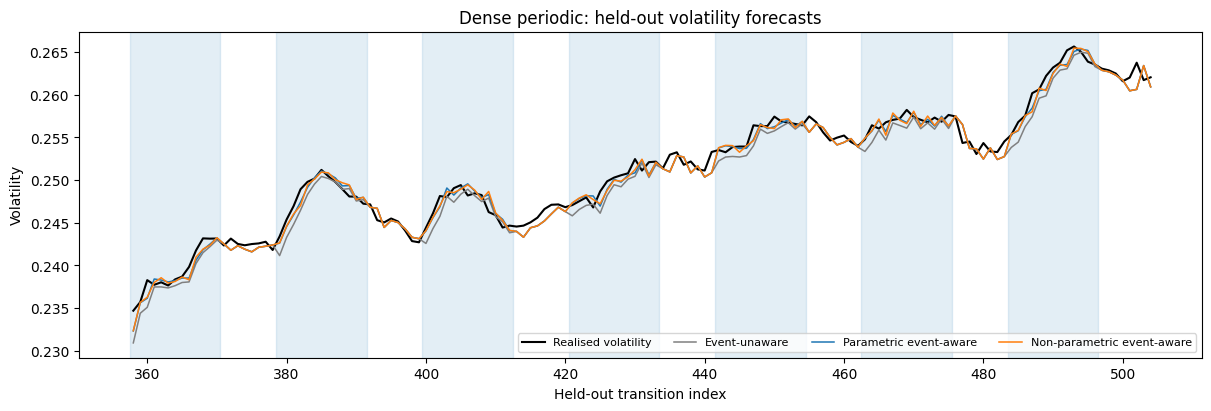

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

In [11]:
show_forecast('dense_periodic', show_metrics=False)

### Step 5 - Prediction accuracy and calibration

In [12]:
show_forecast_metrics('dense_periodic')

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0012,0.0009,0.0009,25.1875,22.1318,0.9470,0.0259,0.0042


In [13]:
schedule_finding('dense_periodic')

Dense periodic finding: forward linear directional predictive evidence rejects in 98% of paired seeds; median AIC order is 7 and the modal strongest direct individual lag is 1. TDMI's global positive peak lies outside the direct window in 72% of seeds, so it remains unsigned nonlinear lagged dependence rather than structural timing. Mean parametric profile RMSE is 0.00034; median active-window parametric MAE gain is 25.19%, with mean absolute 95% coverage error 0.026.

## 3. Sparse periodic analysis

Sparse periodic has 12 events and a deterministic next-event boundary at 42 transitions. The same four-step workflow is retained; the smaller event count affects precision and must not be confused with a pure periodicity effect.

### Step 1 - GC and TDMI analysis

Reverse GC is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

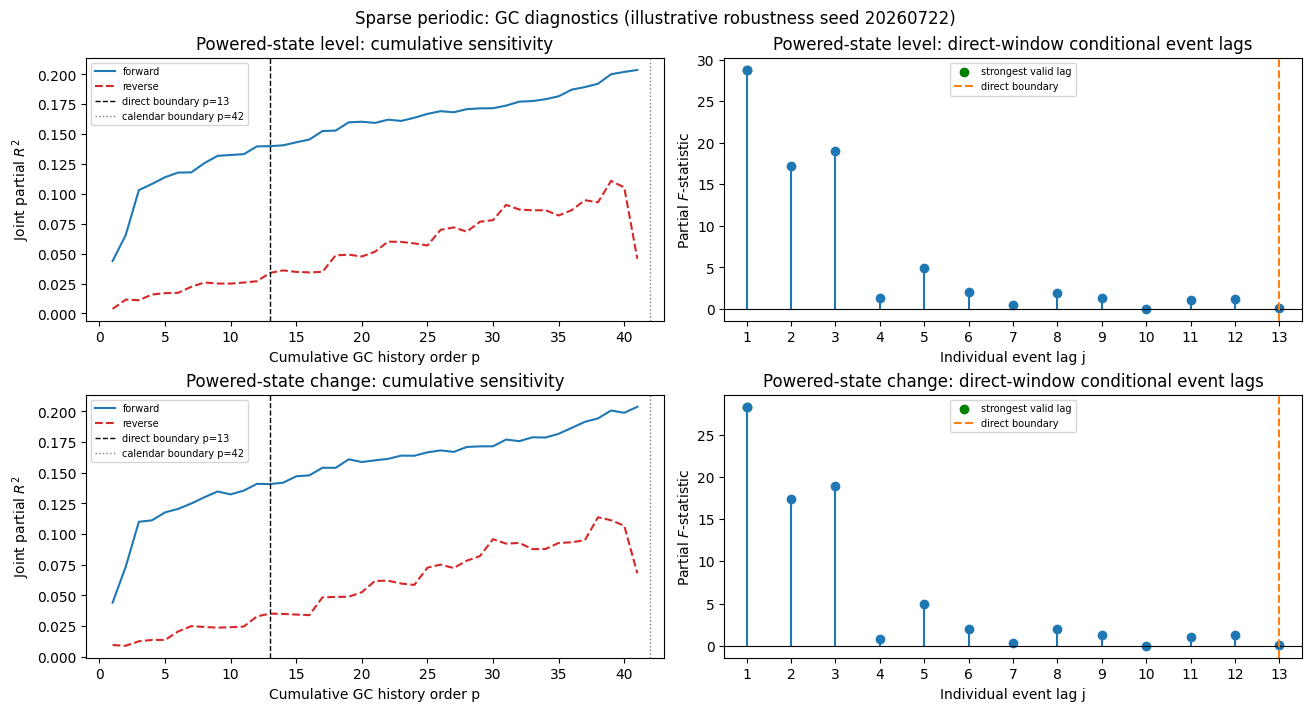

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,4,3,41,17.0332,0.0000,0.1032
1,level,reverse,41,41,39,0.4305,0.9992,0.0458
2,change,forward,3,3,41,18.2535,0.0000,0.1100
3,change,reverse,41,41,38,0.6542,0.9512,0.0681


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0016,28.7664,0.0000,0.0000,True
1,change,1,0.0016,28.2816,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,6.0000,1.0000,0.9400,0.0299,1,16.9268,0.9600
1,level,6.0000,1.0000,0.9400,0.0270,1,16.5931,0.9600


lag,1,2,3,4,5,6,8
target,,,,,,,
change,27,8,4,3,5,1,2
level,27,9,4,3,4,1,2


In [14]:
show_gc('sparse_periodic')

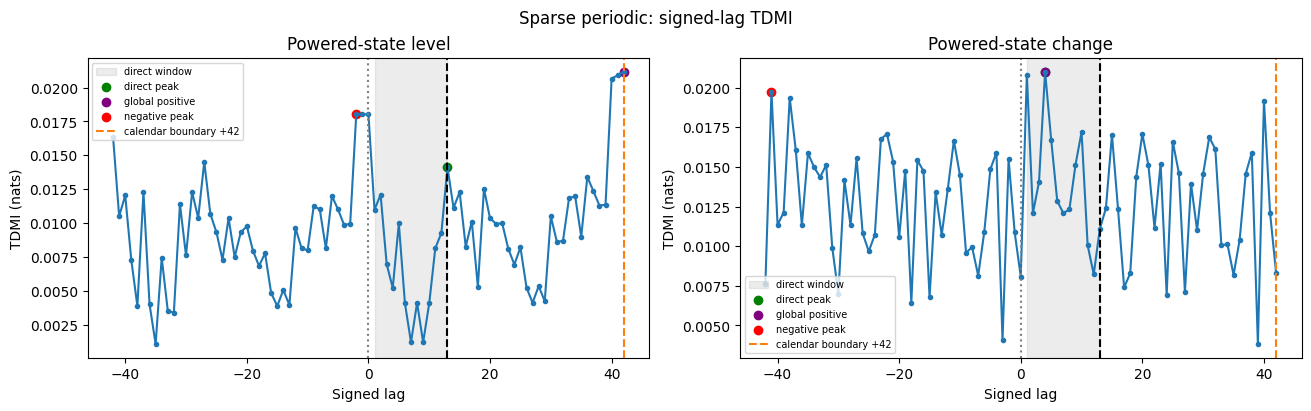

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,13,0.0141,42,0.0212,-2,False,True
1,change,4,0.0210,4,0.0210,-41,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.8000,0.2000,0.9120
1,level,0.3000,0.7000,1.2014


In [15]:
show_tdmi('sparse_periodic')

### Step 3 - Event-weight recovery

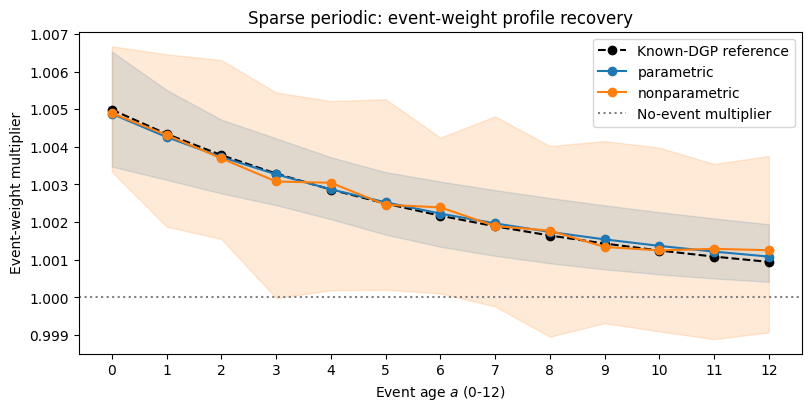

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00978,-0.00022,35.00000,33.34157,-1.65843,0.00055,0.00145


In [16]:
show_profile('sparse_periodic')

### Step 4 - Volatility forecasting

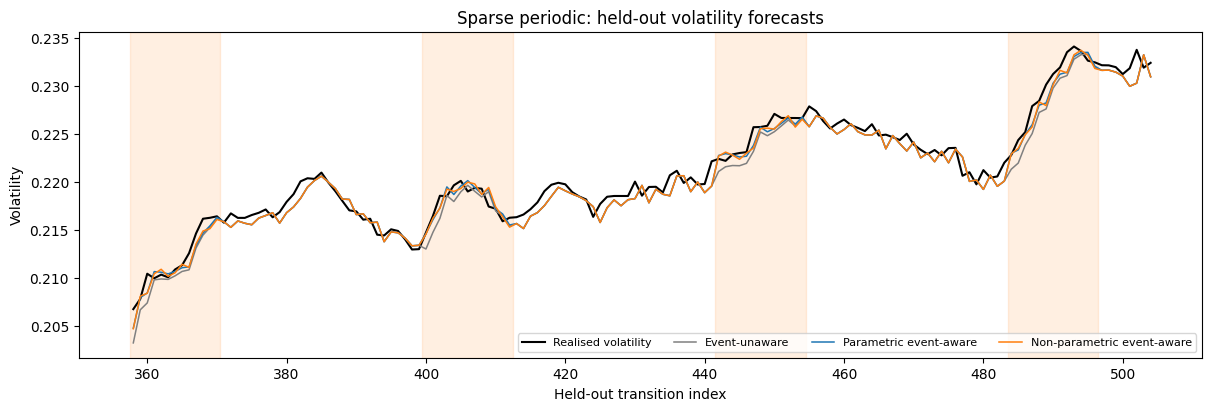

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

In [17]:
show_forecast('sparse_periodic', show_metrics=False)

### Step 5 - Prediction accuracy and calibration

In [18]:
show_forecast_metrics('sparse_periodic')

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0007,0.0011,0.0009,0.0009,19.0049,15.7227,0.9500,0.0286,0.0042


In [19]:
schedule_finding('sparse_periodic')

Sparse periodic finding: forward linear directional predictive evidence rejects in 94% of paired seeds; median AIC order is 6 and the modal strongest direct individual lag is 1. TDMI's global positive peak lies outside the direct window in 20% of seeds, so it remains unsigned nonlinear lagged dependence rather than structural timing. Mean parametric profile RMSE is 0.00055; median active-window parametric MAE gain is 19.00%, with mean absolute 95% coverage error 0.029.

## 4. Sparse irregular analysis

Sparse irregular also has 12 events and retains a nominal period of 42 transitions, but realised spacing ranges from 21 to 69 transitions (median 34). There is no single irregular next-event boundary: wider-lag peaks are reported descriptively.

### Step 1 - GC and TDMI analysis

Reverse GC is a linear predictive diagnostic for a predetermined binary calendar, not structural causality.

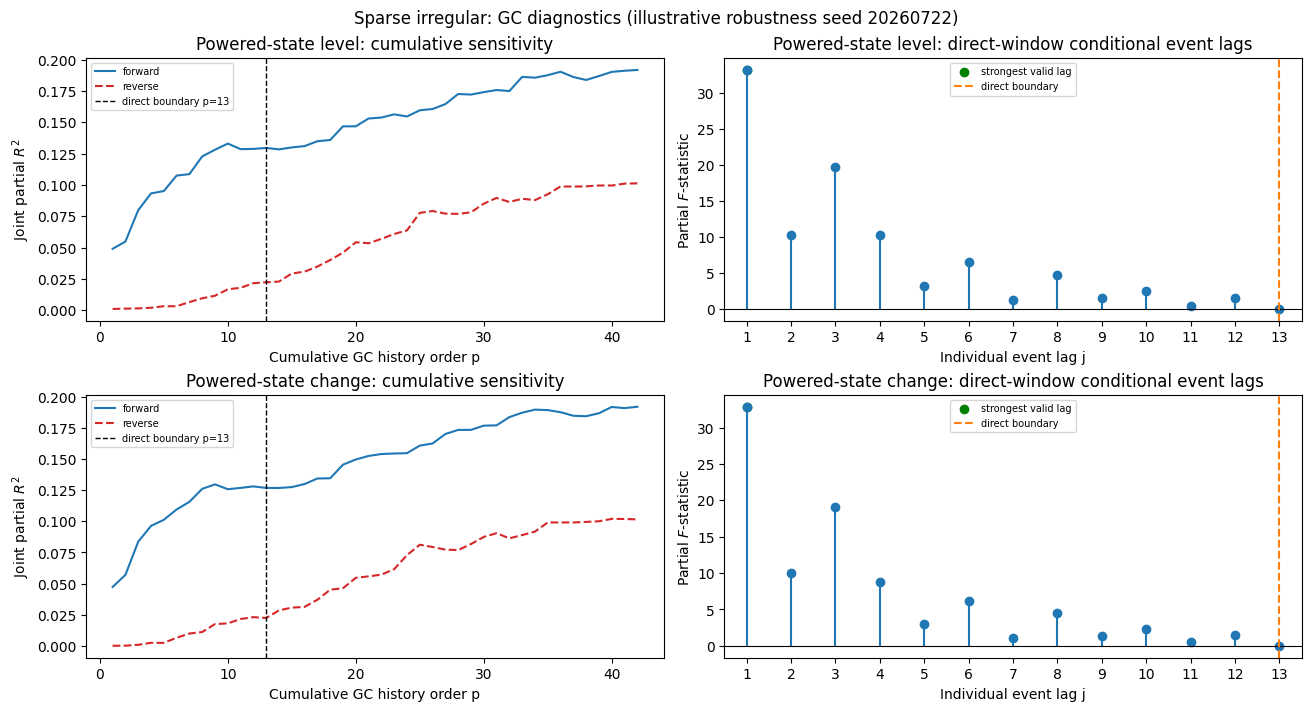

,target,direction,AIC order,BIC order,max partial R2 order,joint F,joint p,partial R2
0,level,forward,8,4,42,11.3369,0.0000,0.0932
1,level,reverse,1,1,42,0.4653,0.4955,0.0010
2,change,forward,8,3,42,13.4467,0.0000,0.0836
3,change,reverse,1,1,40,0.0143,0.9048,0.0000


,target,lag j,coefficient,partial F,raw p,Holm p,survives Holm
0,level,1,0.0017,33.1488,0.0000,0.0000,True
1,change,1,0.0017,32.8613,0.0000,0.0000,True


,target,median_AIC_order,median_BIC_order,rejection_rate,median_partial_R2,modal_strongest_j,median_strongest_F,Holm_survival_rate
0,change,5.0000,1.0000,0.9000,0.0333,1,19.1789,0.9800
1,level,6.0000,1.0000,0.8800,0.0328,1,18.6905,1.0000


lag,1,2,3,4,5,7,13
target,,,,,,,
change,20,15,7,4,2,1,1
level,21,15,7,4,2,0,1


In [20]:
show_gc('sparse_irregular')

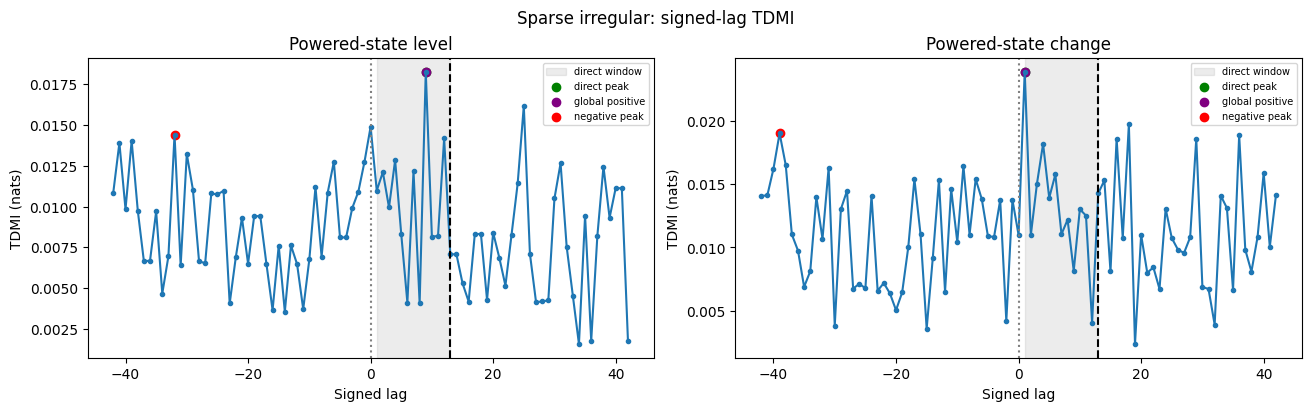

,target,direct lag,direct TDMI,global positive lag,global positive TDMI,negative lag,global inside direct,scan boundary
0,level,9,0.0183,9,0.0183,-32,True,False
1,change,1,0.0239,1,0.0239,-39,True,False


,target,global_positive_inside_direct_rate,outside_window_dominance_rate,median_outside_direct_ratio
0,change,0.7000,0.3000,0.8666
1,level,0.3400,0.6600,1.1388


In [21]:
show_tdmi('sparse_irregular')

### Step 3 - Event-weight recovery

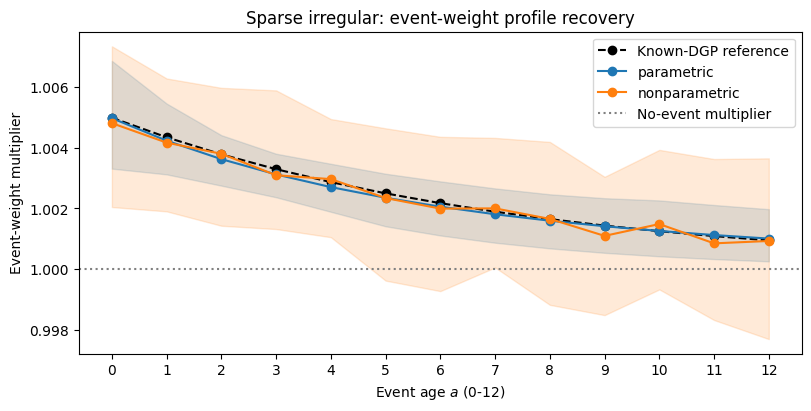

Lines show the central estimate across 50 paired seeds; shaded regions show the 5th-95th percentile range.

,true amplitude,estimated amplitude,amplitude error,true decay,estimated decay,decay error,parametric profile RMSE,non-parametric profile RMSE
0,0.01000,0.00997,-0.00003,35.00000,37.98173,2.98173,0.00058,0.00149


In [22]:
show_profile('sparse_irregular')

### Step 4 - Volatility forecasting

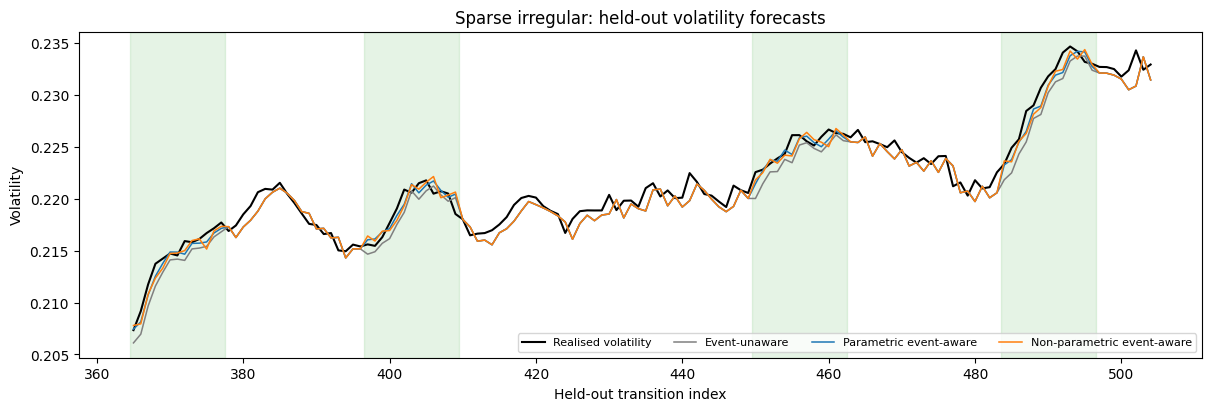

The representative seed is illustrative; forecast-performance conclusions use all 50 paired seeds.

In [23]:
show_forecast('sparse_irregular', show_metrics=False)

### Step 5 - Prediction accuracy and calibration

In [24]:
show_forecast_metrics('sparse_irregular')

,unaware MAE,parametric MAE,non-parametric MAE,unaware RMSE,parametric RMSE,non-parametric RMSE,parametric MAE gain (%),non-parametric MAE gain (%),parametric 95% coverage,coverage error,interval score
0,0.0009,0.0007,0.0008,0.0011,0.0009,0.0009,18.9434,13.4209,0.9392,0.0269,0.0043


In [25]:
schedule_finding('sparse_irregular')

Sparse irregular finding: forward linear directional predictive evidence rejects in 90% of paired seeds; median AIC order is 5 and the modal strongest direct individual lag is 1. TDMI's global positive peak lies outside the direct window in 30% of seeds, so it remains unsigned nonlinear lagged dependence rather than structural timing. Mean parametric profile RMSE is 0.00058; median active-window parametric MAE gain is 18.94%, with mean absolute 95% coverage error 0.027.

## 5. Final comparison across schedules

Only after the three case studies, the table and two figures summarise the paired repeated evidence. Sparse periodic minus dense periodic changes frequency, spacing and event count; sparse irregular minus sparse periodic is the schedule-regularity comparison.

,schedule,forward GC rejection,reverse GC rejection,median forward partial R2,median reverse partial R2,median AIC order,median BIC order,modal strongest lag,Holm survival rate,global positive TDMI inside direct,outside-window dominance,median outside/direct ratio,parametric profile RMSE,non-parametric profile RMSE,parametric active MAE gain,non-parametric active MAE gain,coverage error,interval score
0,Dense periodic,0.9800,0.0200,0.0781,0.0338,7.0000,2.0000,1,1.0000,0.2800,0.7200,1.0758,0.0003,0.0010,25.1875,22.1318,0.0259,0.0042
1,Sparse periodic,0.9400,0.0000,0.0299,0.0756,6.0000,1.0000,1,0.9600,0.8000,0.2000,0.9120,0.0005,0.0014,19.0049,15.7227,0.0286,0.0042
2,Sparse irregular,0.9000,0.0200,0.0333,0.0012,5.0000,1.0000,1,0.9800,0.7000,0.3000,0.8666,0.0006,0.0015,18.9434,13.4209,0.0269,0.0043


,contrast,metric,paired mean difference,95% CI lower,95% CI upper
0,Sparse periodic minus dense periodic,parametric profile RMSE,0.00021,0.00011,0.00030
1,Sparse periodic minus dense periodic,parametric MAE gain,-5.38569,-7.34039,-3.43099
2,Sparse irregular minus sparse periodic,parametric profile RMSE,0.00003,-0.00008,0.00014
3,Sparse irregular minus sparse periodic,parametric MAE gain,-0.69936,-2.67377,1.27505


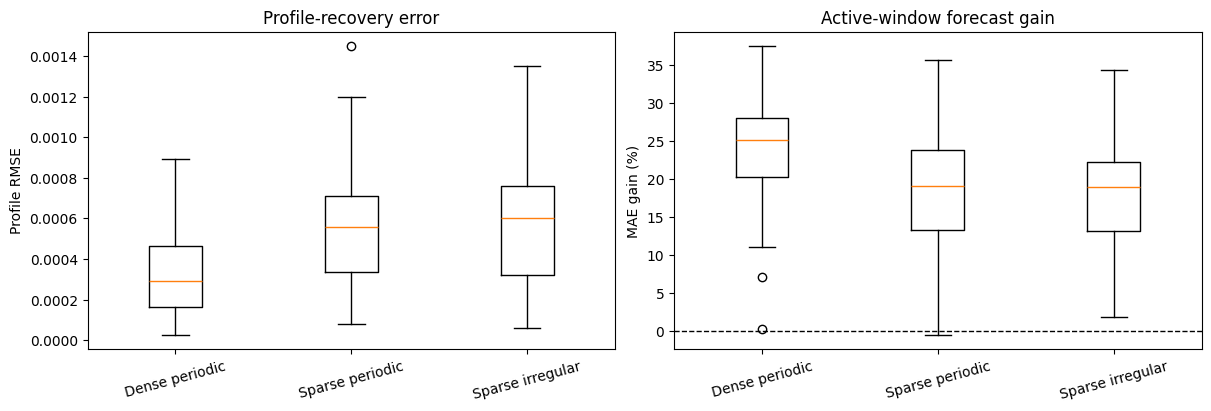

Corrected repeated-seed summary: forward GC rejection is 98%, 94%, and 90%. The two paired contrasts above separate the combined frequency/spacing comparison from the schedule-regularity comparison; reverse GC and TDMI remain predictive/dependence diagnostics.

In [26]:
def paired_ci(values):
    x=np.asarray(values,float); mean=x.mean(); se=x.std(ddof=1)/np.sqrt(len(x)); h=stats.t.ppf(.975,len(x)-1)*se; return mean,mean-h,mean+h
def final_row(case):
    g=gc_repeated.query('case==@case and target=="change" and direction=="forward" and valid_rank'); selected=g.groupby('seed').apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series); ind=individual_repeated.query('case==@case and target=="change"').sort_values('partial_F').groupby('seed',group_keys=False).tail(1); td=tdmi_repeated.query('case==@case and target=="change"'); pr=profile_repeated.query('case_name==@case'); fo=forecast_repeated.query('case_name==@case'); ca=calibration_repeated.query('case_name==@case'); reverse=gc_repeated.query('case==@case and target=="change" and direction=="reverse" and valid_rank').groupby('seed').apply(lambda x: selection_summary(x),include_groups=False).apply(pd.Series)
    return {'schedule':LABEL[case],'forward GC rejection':(selected['joint p']<.05).mean(),'reverse GC rejection':(reverse['joint p']<.05).mean(),'median forward partial R2':selected['partial R2'].median(),'median reverse partial R2':reverse['partial R2'].median(),'median AIC order':selected['AIC order'].median(),'median BIC order':selected['BIC order'].median(),'modal strongest lag':first_mode(ind.lag),'Holm survival rate':ind.holm_reject.mean(),'global positive TDMI inside direct':td.global_positive_inside_direct.mean(),'outside-window dominance':td.alias_dominates.mean(),'median outside/direct ratio':td.alias_strength_ratio.median(),'parametric profile RMSE':pr.parametric_profile_RMSE.mean(),'non-parametric profile RMSE':pr.nonparametric_profile_RMSE.mean(),'parametric active MAE gain':fo.active_sigma_parametric_MAE_gain_pct.median(),'non-parametric active MAE gain':fo.active_sigma_nonparametric_MAE_gain_pct.median(),'coverage error':ca.parametric_absolute_coverage_error.mean(),'interval score':ca.active_95_state_parametric_interval_score.mean()}
final=pd.DataFrame([final_row(k) for k in LABEL]); display(final.style.format(precision=4))
contrast_rows=[]
for name,left,right in [('Sparse periodic minus dense periodic','sparse_periodic','dense_periodic'),('Sparse irregular minus sparse periodic','sparse_irregular','sparse_periodic')]:
    for metric,source in [('parametric profile RMSE',profile_repeated),('parametric MAE gain',forecast_repeated)]:
        col='parametric_profile_RMSE' if metric.startswith('parametric profile') else 'active_sigma_parametric_MAE_gain_pct'; wide=source.pivot(index='market_seed',columns='case_name',values=col); m,lo,hi=paired_ci(wide[left]-wide[right]); contrast_rows.append({'contrast':name,'metric':metric,'paired mean difference':m,'95% CI lower':lo,'95% CI upper':hi})
display(pd.DataFrame(contrast_rows).style.format(precision=5))
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for ax,source,col,title,ylabel in zip(axes,[profile_repeated,forecast_repeated],['parametric_profile_RMSE','active_sigma_parametric_MAE_gain_pct'],['Profile-recovery error','Active-window forecast gain'],['Profile RMSE','MAE gain (%)']): ax.boxplot([source.query('case_name==@k')[col] for k in LABEL],tick_labels=[LABEL[k] for k in LABEL]); ax.axhline(0,color='black',ls='--',lw=1) if 'gain' in col else None; ax.set(title=title,ylabel=ylabel); ax.tick_params(axis='x',rotation=15)
plt.show()
fd=final.set_index('schedule'); display(Markdown(f"Corrected repeated-seed summary: forward GC rejection is {fd.loc['Dense periodic','forward GC rejection']:.0%}, {fd.loc['Sparse periodic','forward GC rejection']:.0%}, and {fd.loc['Sparse irregular','forward GC rejection']:.0%}. The two paired contrasts above separate the combined frequency/spacing comparison from the schedule-regularity comparison; reverse GC and TDMI remain predictive/dependence diagnostics."))

## 6. Concise findings and limitations

The event-response function and scalar parameters remain fixed, and the schedules are synthetic. Conclusions depend on the selected spacing designs. Reverse GC with a binary predetermined calendar is only a linear predictive diagnostic; GC and TDMI do not prove structural causality, and forecast improvement does not guarantee accurate event-profile recovery.

In [27]:
assert BENCHMARK_SEED==reference_config['simulation']['seed']==20260721
assert benchmark_parity_table['pass'].all() and MAX_BENCHMARK_PARITY_DIFFERENCE<=1e-12
assert REPRESENTATIVE_ROBUSTNESS_SEED!=BENCHMARK_SEED and case_results.market_seed.nunique()==N_PAIRED_SEEDS==50
assert P_INDIVIDUAL_ROBUSTNESS==13 and GC_PMAX_ROBUSTNESS=={'dense_periodic':20,'sparse_periodic':41,'sparse_irregular':42}
assert all(no_overlap(v) for v in STEPS_BY_CASE.values())
assert gc_repeated.groupby(['case','target','direction']).size().to_dict()=={(case,target,direction):N_PAIRED_SEEDS*GC_PMAX_ROBUSTNESS[case] for case in LABEL for target in ['level','change'] for direction in ['forward','reverse']}
assert gc_repeated.loc[gc_repeated.valid_rank,'F'].ge(0).all() and gc_repeated.loc[gc_repeated.valid_rank,'p_value'].between(0,1).all()
assert individual_repeated.individual_order.eq(P_INDIVIDUAL_ROBUSTNESS).all() and individual_repeated.partial_F.ge(0).all() and individual_repeated.p_value.between(0,1).all()
assert len(tdmi_repeated)==300 and set(final.schedule)==set(LABEL.values()) and not final.isna().any().any()
for case in LABEL:
 assert not gc_repeated.query('case==@case and target=="change" and direction=="forward" and valid_rank').empty
 assert not gc_repeated.query('case==@case and target=="change" and direction=="reverse" and valid_rank').empty
assert not re_forecast.columns.isin(['sigma_next','omega_next','eta','state_next']).any()
print('Notebook 10 executed: exact dense benchmark parity passed; schedule-specific cumulative scans and separated forward/reverse summaries passed.')

Notebook 10 executed: exact dense benchmark parity passed; schedule-specific cumulative scans and separated forward/reverse summaries passed.
